# Evaluation

In [1]:
import itertools
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Runs

In [2]:
PRICING = {
    'deepseek': {
        'deepseek-v4-pro':   (.435/1e6, .87/1e6),
        'deepseek-v4-flash': (.14/1e6, .28/1e6), 
    },
    'openai': {
        'gpt-5.4':      (2.5/1e6, 15./1e6),
        'gpt-5.4-mini': (.75/1e6, 4.5/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.
        
def load():
    for path in itertools.chain(
        pathlib.Path('runs').glob('*.json'),
        pathlib.Path('runs.deepseek').glob('*.json')):
        with open(path, 'r', encoding='utf-8') as fp:
            t = json.load(fp)
            yield {
                'digest': t['digest'][:10],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                #'provider': t['provider'],
                'model': t['provider'] + '-' + t['model'],
                'prompt': t['prompt'],
                'temperature': t['temperature'],
                'seed': t['seed'],
                'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'progress': t['cycles'] / t['cycles_until_halt'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                # 'input_tokens': t['usage_metadata']['input_tokens'],
                # 'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }
RUNS = list(load())
RUNS_DF = pd.DataFrame(RUNS)
RUNS_DF_SUM = RUNS_DF[['error', 'halted']].sum().to_frame(name='sum')
RUNS_DF_COST = RUNS_DF[['cost']].sum().to_frame(name='$')

In [3]:
from itables import show
display(RUNS_DF_COST)
display(RUNS_DF_SUM)
show(RUNS_DF.sort_values(by=['progress', 'cycles'], ascending=False))

,$
cost,52.169727


,sum
error,155
halted,145


Loading ITables v2.8.0 from the internet... (need help?)


In [4]:
Qs = sorted(RUNS_DF['Q'].unique())
Ss = sorted(RUNS_DF['S'].unique())
Ws = sorted(RUNS_DF['W'].unique())
Cs = sorted(RUNS_DF['C'].unique())
MODEL = RUNS_DF['model'].unique()
PROMPT = RUNS_DF['prompt'].unique()
TEMPERATURE = RUNS_DF['temperature'].unique()
SEED = RUNS_DF['seed'].unique()
TRUNCATE = RUNS_DF['truncate'].unique()
PROD_MODEL_CONFIG = list(itertools.product(MODEL, PROMPT, TEMPERATURE, TRUNCATE))

## Progress

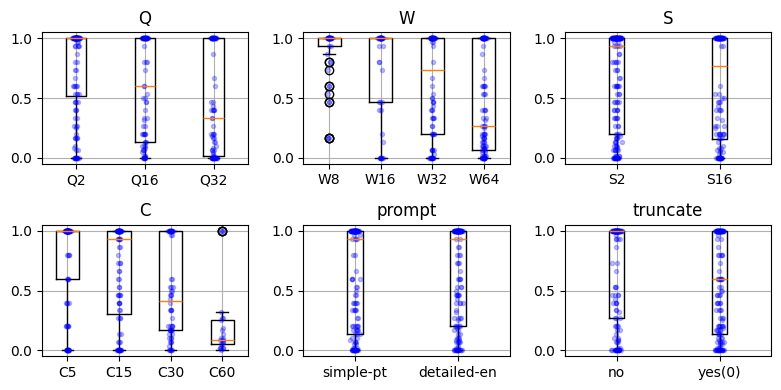

In [5]:
def it(X, Xs, label=None):
    for x in Xs:
        yield (RUNS_DF[(RUNS_DF[X] == x)]['progress'], f'{X if len(X) == 1 else ""}{x}')

fig, ax = plt.subplots(2, 3, figsize=(8,4))
for k, (X, Xs) in enumerate((
    ('Q', Qs), ('W', Ws), ('S', Ss), ('C', Cs), ('prompt', PROMPT), ('truncate', TRUNCATE))):
    xs, labels = zip(*it(X, Xs))
    i, j = k//3, k%3
    #print(k, i, j)
    ax[i, j].boxplot(xs, tick_labels=labels)
    ax[i, j].grid(True)
    ax[i, j].set_title(X)
    for l in range(1, len(xs) + 1):
        y = xs[l-1]
        x = np.random.normal(l, 0.02, len(y))
        ax[i,j].plot(x, y, 'b.', alpha=0.25)
plt.tight_layout()
plt.show()

## Accuracy

In [6]:
# providers = RUNS_DF['provider'].unique()
# models = RUNS_DF['model'].unique()
# prompts = RUNS_DF['prompt'].unique()
# temperature = RUNS_DF['temperature'].unique()
# truncate = RUNS_DF['truncate'].unique()
# Cs = RUNS_DF['C'].unique()
# Cs.sort()

In [7]:
import itertools
tab = {}
for model, prompt, temp, tr in PROD_MODEL_CONFIG:
    t = RUNS_DF[
        (RUNS_DF['model'] == model)
        & (RUNS_DF['prompt'] == prompt)
        & (RUNS_DF['temperature'] == temp)
        & (RUNS_DF['truncate'] == tr)
    ].sort_values('cycles')
    label = f'{model}-{prompt}-temp:{temp}-tr:{tr}'
    #print(label)
    for i in range(0, Cs[-1] + 1):
        N_correct = len(t[t['cycles'] >= i])
        N_total = len(t[t['C'] >= i])
        if N_total != 0:
            acc = N_correct / N_total
        else:
            acc = float('nan')
        if label not in tab:
            tab[label] = []
        tab[label].append(acc)

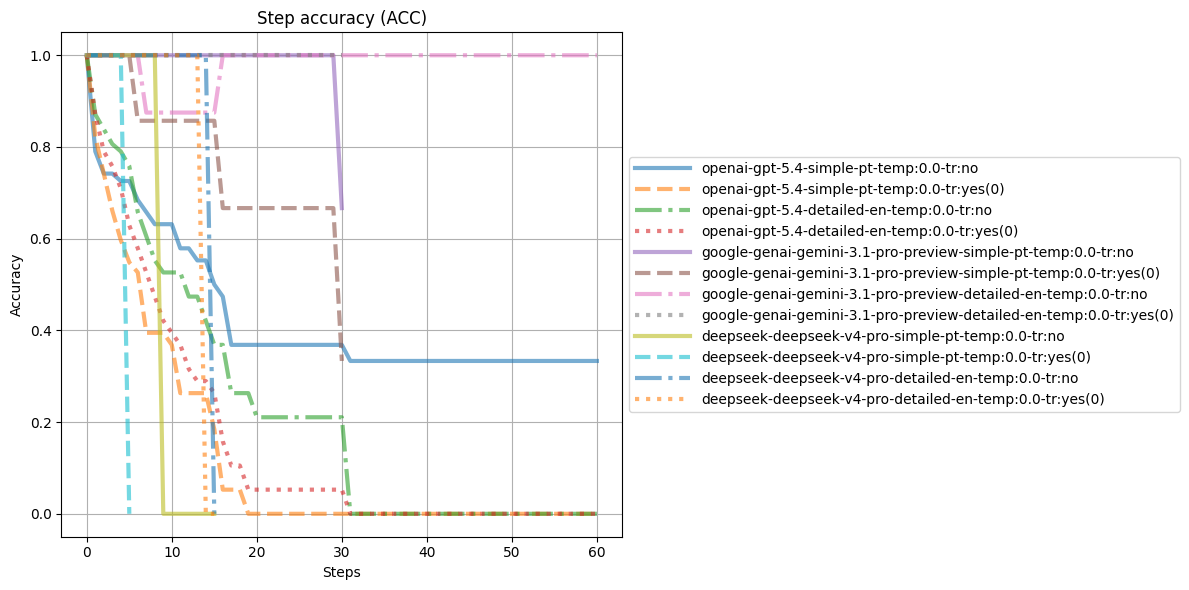

In [8]:
from itertools import cycle, islice
df = pd.DataFrame(tab, index=list(range(0, Cs[-1]+1)))
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(1, 1, 1)
df.plot.line(
    ax = ax,
    title='Step accuracy (ACC)',
    xlabel='Steps',
    ylabel='Accuracy',
    figsize=(12,6),
    grid=True, 
    style=list(islice(cycle(["-","--","-.",":"]), len(df))), 
    alpha=.6,
    linewidth=3,
)
#ax.set_ylim(df.min().min(), df.max().max())
ax.legend(loc='center left', bbox_to_anchor=(1, .5), handlelength=4)
fig.tight_layout()
plt.show()

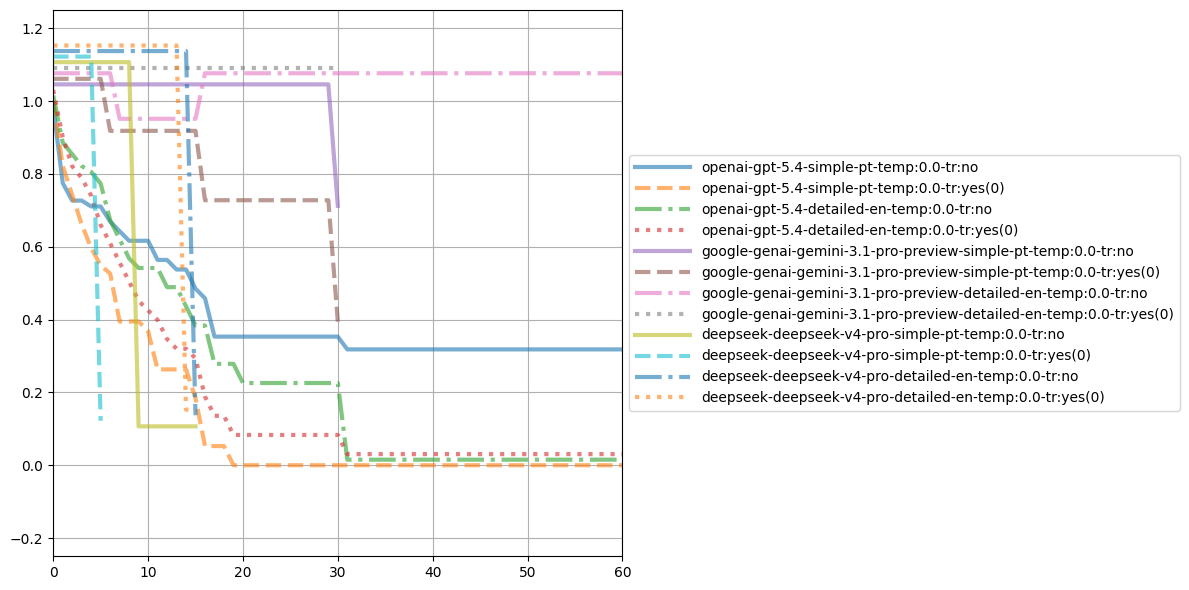

In [9]:
from itertools import cycle, islice
import matplotlib.transforms as mtrans
fig, ax = plt.subplots(figsize=(16,9))
ax.set_ylim(-0.25, 1.25)
ax.set_xlim(0, 60)
ls = list(islice(cycle(["-","--","-.",":"]), len(df)))
for i, col in enumerate(df):
    df.plot(y=col, figsize=(12,6), ax=ax, alpha=.6, linewidth=3, style=ls[i],
            transform=mtrans.offset_copy(ax.transData, fig=fig, x=0.0, y=4*(i-1), units='points'))
ax.legend(loc='center left', bbox_to_anchor=(1, .5), handlelength=4)
ax.grid(True)
fig.tight_layout()
plt.show()